# 04 - Final EDA

Polished EDA behind the report, the presentation and the Streamlit app.
Notebook 03 stays as the exploratory version. Figure functions live in
`src/plots.py` so the app draws exactly the same charts; final figures are saved
to `figures/final/`.

Everything is **associational**. Market value is Transfermarkt's estimate, not a
price. Value is plotted on a log scale (see section 2). Per-90 rates use only
rows with at least 450 minutes.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from src.data import *
from src.plots import *

FIG = ROOT / "figures" / "final"; FIG.mkdir(parents=True, exist_ok=True)
def save(fig, name): fig.savefig(FIG / name, dpi=150, bbox_inches="tight"); plt.show()

df = load_player_season()
elig = df[df["analysis_minutes_eligible"]]

## 1. Dataset overview

In [2]:
print(f"{len(df):,} player-seasons | {df.player_id.nunique():,} distinct players | {df.competition.nunique()} leagues | seasons {season_label(df.season.min())} to {season_label(df.season.max())}")
print(f"per-90 eligible (>= {MIN_MINUTES} min): {len(elig):,} ({len(elig)/len(df):.1%})")
pd.concat({"player-seasons": df.position.value_counts(), "per-90 eligible": elig.position.value_counts()}, axis=1).reindex(POS_ORDER)

32,046 player-seasons | 13,511 distinct players | 14 leagues | seasons 2020/21 to 2024/25
per-90 eligible (>= 450 min): 23,328 (72.8%)


,player-seasons,per-90 eligible
position,,
Goalkeeper,2560,1756
Defender,10942,8601
Midfield,9428,6876
Attack,9116,6095


In [3]:
df[[MV, "age", "total_minutes", "goals_per_90", "goal_contributions_per_90"]].describe().round(2).T.assign(
    note=["EUR", "years at Aug 1", "season total", "all rows (unstable below 450 min)", "all rows (unstable below 450 min)"])

,count,mean,std,min,25%,50%,75%,max,note
market_value_in_eur,32046.0,5447824.07,11685379.53,20000.0,425000.0,1300000.0,5000000.00,200000000.0,EUR
age,32046.0,25.62,4.56,15.3,22.1,25.3,28.90,42.9,years at Aug 1
total_minutes,32046.0,1209.69,902.00,1.0,386.0,1108.0,1904.00,3420.0,season total
goals_per_90,32046.0,0.13,0.97,0.0,0.0,0.0,0.16,90.0,all rows (unstable below 450 min)
goal_contributions_per_90,32046.0,0.23,1.13,0.0,0.0,0.1,0.31,90.0,all rows (unstable below 450 min)


## 2. Market-value distribution

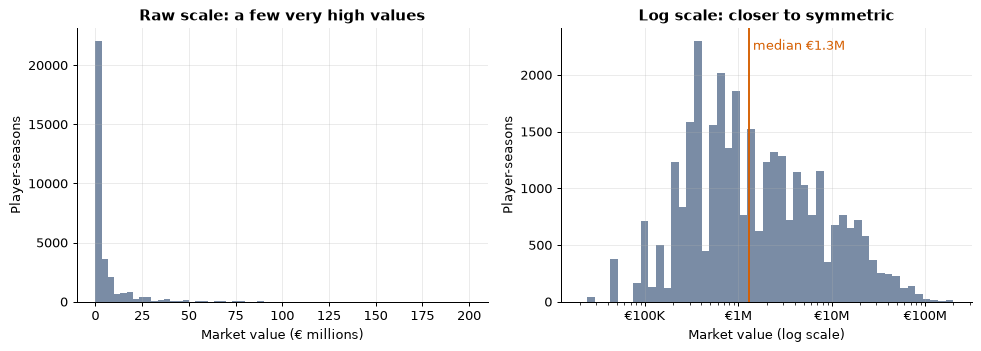

skewness raw = 5.25; skewness of log10 value = 0.28
count        32046.0
mean       5447824.0
std       11685380.0
min          20000.0
10%         225000.0
50%        1300000.0
90%       15000000.0
99%       60000000.0
max      200000000.0


In [4]:
save(fig_value_distribution(df), "01_value_distribution.png")
print(f"skewness raw = {df[MV].skew():.2f}; skewness of log10 value = {df[LOGMV].skew():.2f}")
print(df[MV].describe(percentiles=[.1,.5,.9,.99]).round(0).to_string())

**Reading:** the raw histogram is dominated by a long right tail (median about
€1.3M, maximum €200M). On the log scale the shape is close to symmetric, so
medians, ratios and rank correlations are meaningful. Every value chart below
uses a log axis and medians rather than means.

## 3. Age

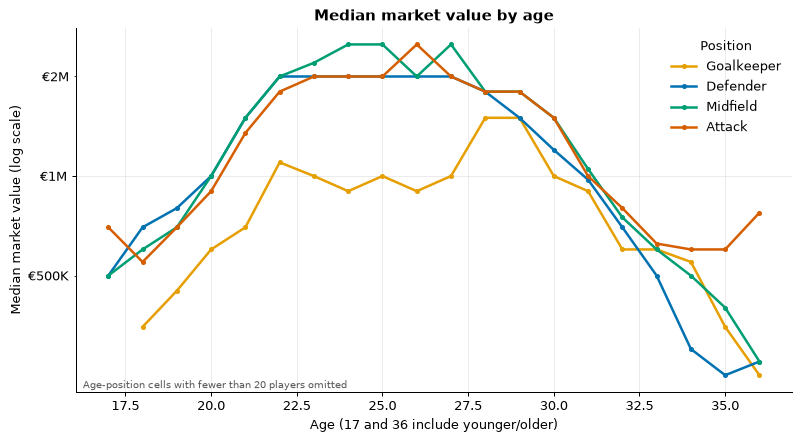

Spearman(age, value) = -0.034 <- near zero because the pattern is a hump, not a line


,median value (EUR),player-seasons
age_group,,
Under 21,800000.0,5371
21-23,1800000.0,7325
24-26,2000000.0,7344
27-29,1800000.0,5932
30+,750000.0,6074


In [5]:
save(fig_value_by_age(df), "02_value_by_age.png")
print("Spearman(age, value) =", round(spearmanr(df.age, df[LOGMV])[0], 3), "<- near zero because the pattern is a hump, not a line")
(df.groupby("age_group")[MV].agg(["median", "size"]).reindex(AGE_GROUPS)
   .rename(columns={"median": "median value (EUR)", "size": "player-seasons"}))

**Reading:** median value rises through the early 20s, plateaus at roughly
€1.8-2.5M from about age 22 to 28 for outfield players, then falls steeply after
30. Goalkeepers sit lower throughout and peak slightly later. A single linear
correlation (about -0.03) hides this, so age should be read from the curve or
the age groups, not from one coefficient.

## 4. Position

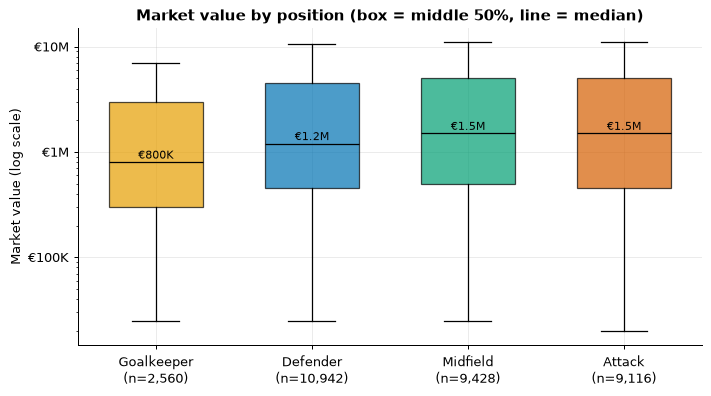

,count,mean,std,min,25%,50%,75%,max
position,,,,,,,,
Goalkeeper,2560.0,3416992.0,7029274.0,25000.0,300000.0,800000.0,3000000.0,70000000.0
Defender,10942.0,4872740.0,9456780.0,25000.0,450000.0,1200000.0,4500000.0,80000000.0
Midfield,9428.0,5909835.0,12566279.0,25000.0,500000.0,1500000.0,5000000.0,180000000.0
Attack,9116.0,6230586.0,13897104.0,20000.0,450000.0,1500000.0,5000000.0,200000000.0


In [6]:
save(fig_value_by_position(df), "03_value_by_position.png")
df.groupby("position")[MV].describe(percentiles=[.25,.5,.75]).reindex(POS_ORDER).round(0)

**Reading:** position matters much less than intuition suggests: outfield
medians are close (Attack and Midfield €1.5M, Defender €1.2M) and goalkeepers
are lowest (€0.8M). Position explains about 1% of the variance in log value
(section 10), far less than league.

## 5. Playing time

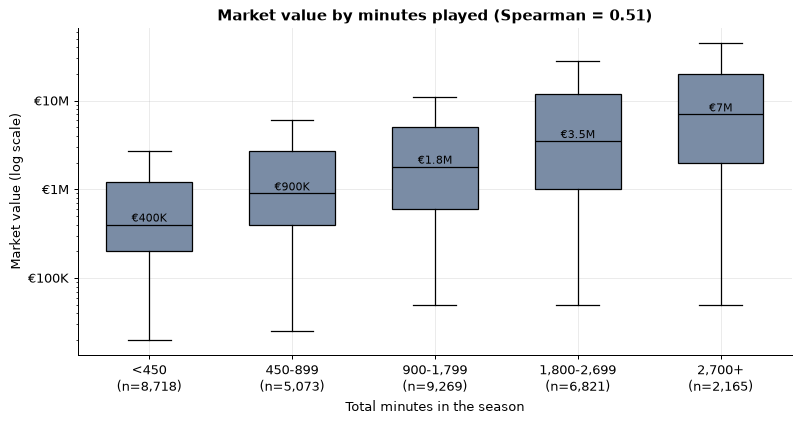

Spearman(total_minutes, value) = 0.51
Spearman(appearances, value) = 0.54
Spearman(minutes_per_appearance, value) = 0.26
{'Goalkeeper': np.float64(0.57), 'Defender': np.float64(0.47), 'Midfield': np.float64(0.53), 'Attack': np.float64(0.56)}


In [7]:
save(fig_value_vs_minutes(df), "04_value_by_minutes.png")
for c in ["total_minutes", "appearances", "minutes_per_appearance"]:
    print(f"Spearman({c}, value) = {spearmanr(df[c], df[LOGMV])[0]:.2f}")
print({p: round(spearmanr(df[df.position==p].total_minutes, df[df.position==p][LOGMV])[0], 2) for p in POS_ORDER})

**Reading:** value rises steadily with minutes played (Spearman about 0.51,
0.47-0.57 within each position). This runs both ways: clubs play players they
value, and playing more may raise value. The chart cannot separate the two. It
also partly reflects league, since bigger clubs' squads have higher values and
different rotation.

## 6. Performance by position

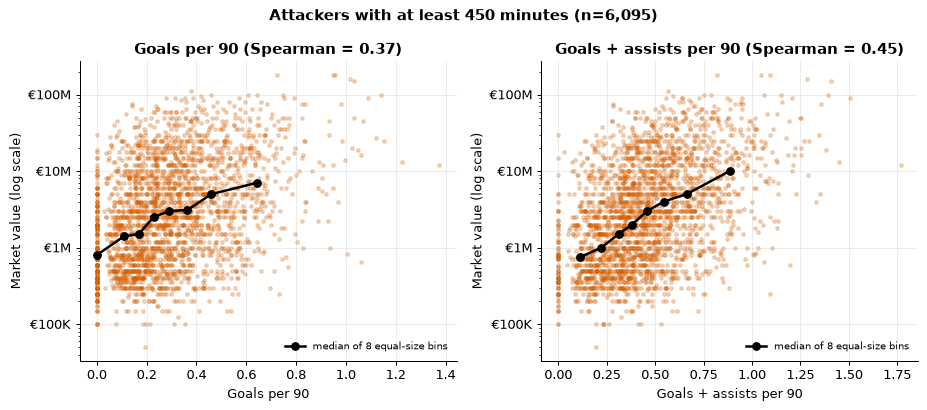

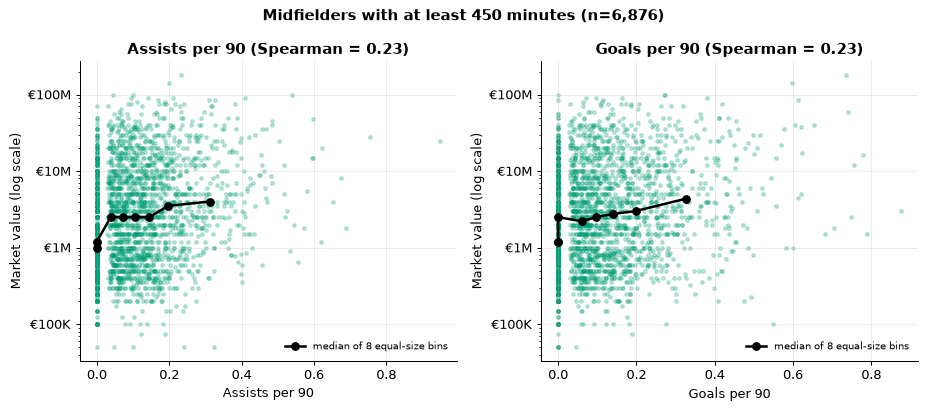

,n,goals_per_90,assists_per_90,goal_contributions_per_90
position,,,,
Attack,6095,0.37,0.30,0.45
Midfield,6876,0.23,0.23,0.26
Defender,8601,0.18,0.16,0.19
Goalkeeper,1756,0.04,0.09,0.10


In [8]:
save(fig_perf_vs_value(df, "Attack", ["goals_per_90", "goal_contributions_per_90"]), "05_attackers_performance.png")
save(fig_perf_vs_value(df, "Midfield", ["assists_per_90", "goals_per_90"]), "06_midfielders_performance.png")
rows = []
for p in ["Attack", "Midfield", "Defender", "Goalkeeper"]:
    s = elig[elig.position == p]
    rows.append({"position": p, "n": len(s), **{m: round(spearmanr(s[m], s[LOGMV])[0], 2) for m in PERF_LABELS}})
pd.DataFrame(rows).set_index("position")

**Reading:** Spearman(goals + assists per 90, value) is 0.45 for attackers,
0.26 for midfielders and 0.19 for defenders; for goalkeepers goals and assists
say almost nothing (about 0.1). Binned medians rise for attackers across the
whole range, while for midfielders the increase is weaker. Even for attackers a
large spread remains at any output level, so per-90 output is one moderate
factor, not a determinant. Goals and assists are not a quality measure for
defenders or goalkeepers, and the data has no defensive or goalkeeping
statistics.

## 7. League context

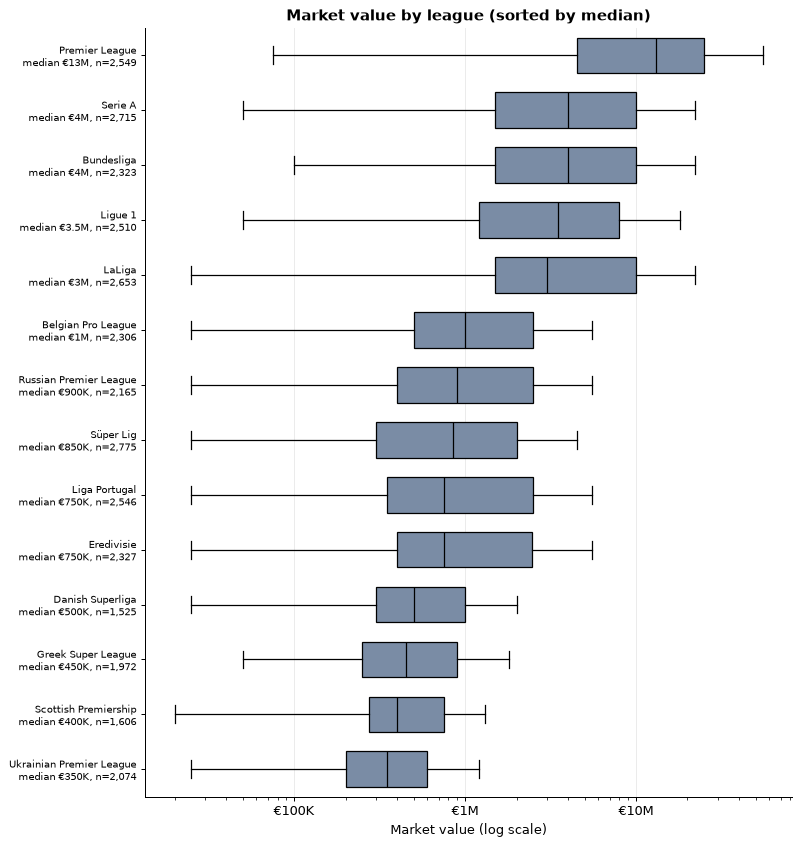

Premier League median is 37x the lowest league median (Ukrainian Premier League)


In [9]:
save(fig_value_by_league(df), "07_value_by_league.png")
lg = df.groupby("competition")[MV].median().sort_values(ascending=False)
print(f"Premier League median is {lg.iloc[0]/lg.iloc[-1]:.0f}x the lowest league median ({lg.index[-1]})")

**Reading:** market-value distributions differ substantially between leagues:
the Premier League median (€13M) is about 37x the Ukrainian league median
(€0.35M), and there is a clear gap between five large leagues (LaLiga, Ligue 1,
Bundesliga, Serie A, Premier League) and the other nine. This says nothing about
why: league is bundled with club wealth, revenue and player pool. 2022+ seasons
in the Russian and Ukrainian leagues are affected by the war.

## 8. Position x league

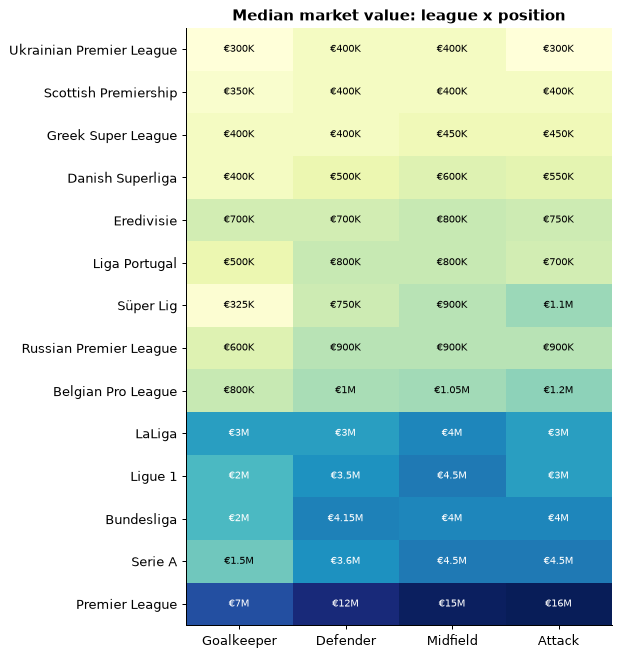

In [10]:
save(fig_position_league_heatmap(df), "08_position_league_heatmap.png")

**Reading:** goalkeepers are the lowest-valued position in nearly every league.
Position gaps are small in the smaller leagues and largest in the Premier League
(goalkeeper €7M vs attack €16M), but differences between leagues (e.g. €0.3M to
€16M for attackers) are much larger than differences between positions.

## 9. Sub-position

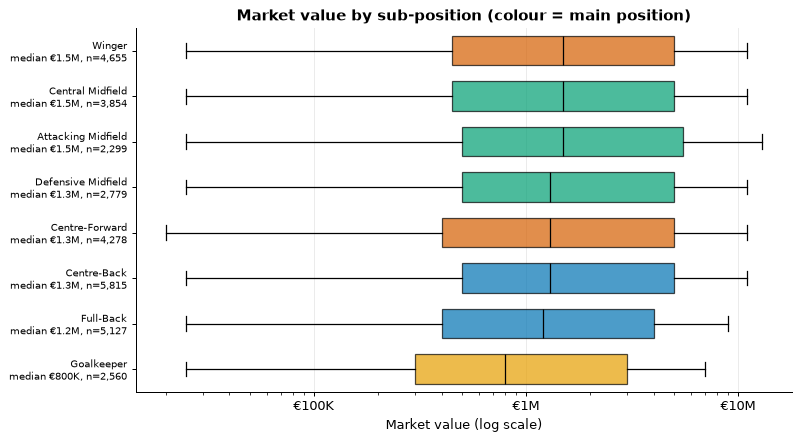

dropped for readability (small): {'Right Midfield': 265, 'Left Midfield': 231, 'Second Striker': 183}


In [11]:
save(fig_value_by_subposition(df), "09_value_by_subposition.png")
print("dropped for readability (small):", df[~df.sub_position.isin(SUBPOS_GROUP)].sub_position.value_counts().to_dict())

**Reading:** sub-positions add little beyond main position: medians of the
eight groups fall between about €0.8M (goalkeepers) and €1.5M. Left/Right
Midfield and Second Striker are omitted (fewer than 300 rows each).

## 10. Association summary

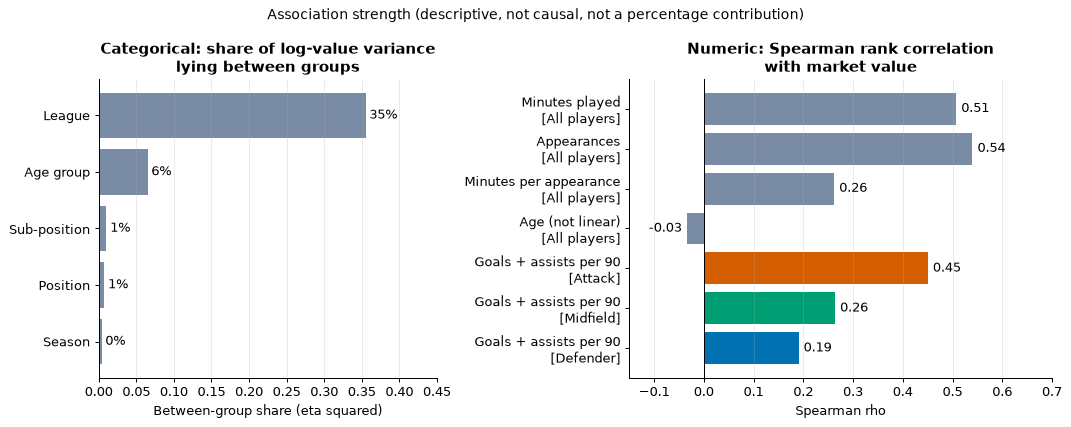

Season          0.004
Position        0.007
Sub-position    0.010
Age group       0.065
League          0.355
              variable       group  spearman
        Minutes played All players      0.51
           Appearances All players      0.54
Minutes per appearance All players      0.26
      Age (not linear) All players     -0.03
Goals + assists per 90      Attack      0.45
Goals + assists per 90    Midfield      0.26
Goals + assists per 90    Defender      0.19


In [12]:
eta, sp = association_tables(df)
save(fig_association_summary(df), "10_association_summary.png")
print(eta.round(3).to_string()); print(sp.round(2).to_string(index=False))

This replaces any "percentage influence" chart, which the data cannot support.
Left: the share of variance in log value that lies between groups of a
categorical variable (eta squared). Right: rank correlations for numeric
variables. The two panels use different measures and **must not be added
together or compared as shares**. The measures are not independent either:
league, minutes and age are all related.

### Is the pattern just league?  Within-league check

In [13]:
def within(col, data):
    r = {lg: spearmanr(g[col], g[LOGMV])[0] for lg, g in data.groupby("competition") if len(g) > 100}
    return pd.Series(r)
w1 = within("total_minutes", df); w2 = within("goal_contributions_per_90", elig[elig.position == "Attack"])
print(f"minutes: pooled {spearmanr(df.total_minutes, df[LOGMV])[0]:.2f}; within-league median {w1.median():.2f} (range {w1.min():.2f} to {w1.max():.2f})")
print(f"attackers' goals+assists/90: pooled {spearmanr(elig[elig.position=='Attack'].goal_contributions_per_90, elig[elig.position=='Attack'][LOGMV])[0]:.2f}; within-league median {w2.median():.2f} (range {w2.min():.2f} to {w2.max():.2f})")

minutes: pooled 0.51; within-league median 0.56 (range 0.37 to 0.63)
attackers' goals+assists/90: pooled 0.45; within-league median 0.53 (range 0.38 to 0.59)


## 11. Main findings

1. Log-scaled market value is close to symmetric; raw values are extremely right-skewed.
2. Age is a hump: values plateau at about 22-28 and fall after 30; one linear coefficient is misleading.
3. League is the largest single grouping in these data (about 35% of log-value variance lies between leagues), far more than position (1%) or age group (6%).
4. Playing time is the strongest simple numeric association (Spearman about 0.5) but works both ways.
5. Goal contributions per 90 are more associated with value for attackers (0.45) than for midfielders (0.26) or defenders (0.19).
6. Sub-position adds little beyond main position.

## 12. Limitations

- Transfermarkt values are estimates with their own timing and biases, not prices or fees.
- Associations are not causal; age, minutes, output, club and league overlap.
- League and club strength are only partly captured (league yes, club no).
- No defensive, goalkeeping, injury, contract or international data; attacking output is meaningful mainly for attackers and midfielders.
- Per-90 rates require at least 450 minutes (a practical choice); low-minute players are kept elsewhere.
- The July-31 valuation rule and 365-day cap are analytical decisions.
- The same player appears in several seasons, so rows are not independent.